In [1]:
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}, GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.10.1, GPU: True


In [2]:
(train_X, train_Y), (test_X, test_Y) = tf.keras.datasets.cifar10.load_data()

train_X = tf.cast(train_X, tf.float32) / 255.0
test_X = tf.cast(test_X, tf.float32) / 255.0

print(f"Training data shape: {train_X.shape}")  # (50000, 32, 32, 3)
print(f"Training labels shape: {train_Y.shape}")  # (50000, 1)
print(f"Test data shape: {test_X.shape}")  # (10000, 32, 32, 3)
print(f"Test labels shape: {test_Y.shape}")  # (10000, 1)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [3]:
image_size = 32
patch_size = 4
num_patches = (image_size // patch_size) ** 2

assert image_size % patch_size == 0, f"Image size ({image_size}) must be divisible by patch size ({patch_size})"
print(f"Image size is divisible by patch size and num of patches {num_patches}")

d_model = 64  #embedding dimension
num_heads = 4  # MHA head count
num_layers = 3  # transformer block to be repeated
num_classes = 10

Image size is divisible by patch size and num of patches 64


In [4]:

# Patch Embedding
# -----------------------------
class PatchEmbedding(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.proj = tf.keras.layers.Conv2D(filters=d_model,
                                           kernel_size=patch_size,
                                           strides=patch_size)

    def call(self, x):
        #  [batch,32,32,3]
        x = self.proj(x)  # [batch, 8, 8, 128]
        x = tf.reshape(x, [tf.shape(x)[0], -1, d_model])  # [batch, 64, 128]
        return x


# Positional Encoding
# -----------------------------
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        self.pos_emb = self.add_weight(shape=(1, num_patches, d_model),
                                       # initializer="random_normal"
                                       initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
                                       name="pos_embedding")

    def call(self, x):
        return x + self.pos_emb  # [1, 64, 128]


# Transformer Block
# -----------------------------
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__()
        # key_dim = d_model // num_heads = 32
        self.mha = tf.keras.layers.MultiHeadAttention(num_heads=num_heads,
                                                      key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='gelu'),  # gelu works better than relu in transformers
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(0.1),
        ])

        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout = tf.keras.layers.Dropout(0.1)

    def call(self, x, training=False):
        # (1, 64, 128)
        # attn = self.mha(x, x, training=training)  # (1, 64, 32 x 4) -> (1, 64, 128)
        attn = self.mha(query=x, key=x, value=x, training=training)
        attn = self.dropout(attn, training=training)  # (1, 64, 128)
        x = self.norm1(x + attn)  # (1, 64, 128)

        ffn_out = self.ffn(x, training=training)
        return self.norm2(x + ffn_out)


# Vision Transformer Model
# -----------------------------
class ViT(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.patch_embed = PatchEmbedding()
        self.pos_encoding = PositionalEncoding()

        self.transformer_blocks = []
        for i in range(num_layers):
            block = TransformerBlock()
            setattr(self, f'transformer_block_{i}', block)
            self.transformer_blocks.append(block)
        # self.transformer_blocks = [    TransformerBlock() for _ in range(num_layers)]

        self.pool = tf.keras.layers.GlobalAveragePooling1D()
        self.classifier = tf.keras.layers.Dense(num_classes)

    def call(self, x):
        x = self.patch_embed(x)
        x = self.pos_encoding(x)

        for block in self.transformer_blocks:
            x = block(x)

        x = self.pool(x)
        x = self.classifier(x)
        return x


model = ViT()
dummy_input = tf.random.normal([1, 32, 32, 3])
dummy_output = model(dummy_input)
print(dummy_output.shape)


(1, 10)


In [5]:
model.summary()

Model: "vi_t"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 patch_embedding (PatchEmbed  multiple                 3136      
 ding)                                                           
                                                                 
 positional_encoding (Positi  multiple                 4096      
 onalEncoding)                                                   
                                                                 
 transformer_block (Transfor  multiple                 49984     
 merBlock)                                                       
                                                                 
 transformer_block_1 (Transf  multiple                 49984     
 ormerBlock)                                                     
                                                                 
 transformer_block_2 (Transf  multiple                 49984  

In [6]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer=Adam(learning_rate=3e-4), metrics=["accuracy"])

callbacks = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
             ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1),
             # ModelCheckpoint('CIFAR10.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
             ]

history = model.fit(train_X, train_Y, validation_data=(test_X, test_Y), epochs=50,
                    batch_size=128, callbacks=callbacks, verbose=1)

Epoch 1/50
391/391 [==============================] - 9s 16ms/step - loss: 1.8988 - accuracy: 0.2877 - val_loss: 1.6446 - val_accuracy: 0.3961 - lr: 3.0000e-04
Epoch 2/50
391/391 [==============================] - 6s 14ms/step - loss: 1.5392 - accuracy: 0.4358 - val_loss: 1.4565 - val_accuracy: 0.4745 - lr: 3.0000e-04
Epoch 3/50
391/391 [==============================] - 6s 14ms/step - loss: 1.3800 - accuracy: 0.4984 - val_loss: 1.3385 - val_accuracy: 0.5133 - lr: 3.0000e-04
Epoch 4/50
391/391 [==============================] - 5s 14ms/step - loss: 1.2902 - accuracy: 0.5314 - val_loss: 1.2645 - val_accuracy: 0.5398 - lr: 3.0000e-04
Epoch 5/50
391/391 [==============================] - 5s 14ms/step - loss: 1.2271 - accuracy: 0.5558 - val_loss: 1.2469 - val_accuracy: 0.5538 - lr: 3.0000e-04
Epoch 6/50
391/391 [==============================] - 6s 14ms/step - loss: 1.1760 - accuracy: 0.5762 - val_loss: 1.1685 - val_accuracy: 0.5835 - lr: 3.0000e-04
Epoch 7/50
391/391 [====================

In [7]:
model.evaluate(test_X, test_Y)

# Getting predicted classes
logits = model.predict(test_X)  # raw logits
probs = tf.nn.softmax(logits, axis=-1)  # convert to probabilities
predicted_classes = tf.argmax(probs, axis=-1)  # get class index

# Or in one line
# predicted_classes = tf.argmax(model.predict(test_X), axis=-1)  # argmax of logits == argmax of softmax, mathematically identical

313/313 [==============================] - 2s 5ms/step


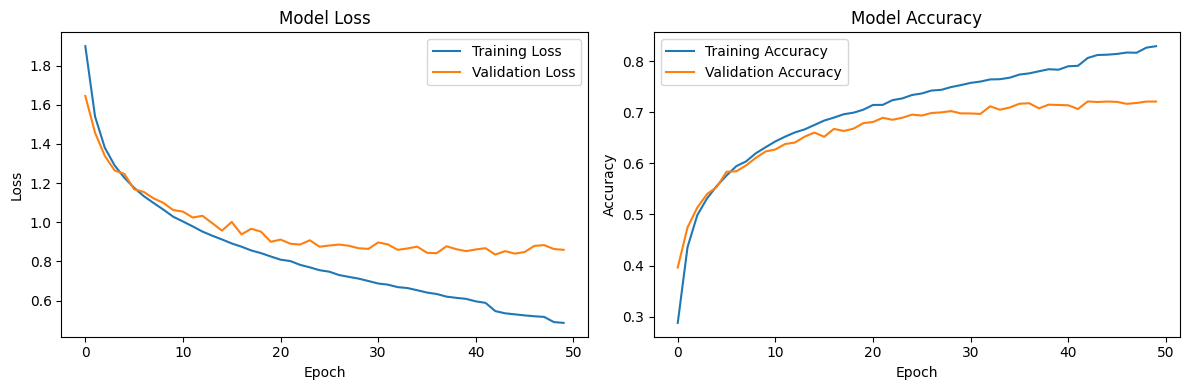

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()